# 06 · Machine learning: LightGBM

HAR-X, the best model so far, is **linear**: each feature moves the forecast by a fixed amount, whatever the situation. This step tests whether a **non-linear** model can extract more from the same features.

As in all the following steps, the benchmark is **HAR-X**, not a baseline: it is the best model without machine learning, LightGBM starts from the same features (so the comparison measures the algorithm, not extra data), and it is the cheap, transparent model that a complex one has to beat to justify its cost. The full reasoning is in section 7 of notebook 05.

**LightGBM** (*Light Gradient Boosting Machine*) builds hundreds of small decision trees one after the other, each one correcting the errors left by the previous ones. It can learn thresholds ("the VIX only matters above 25") and interactions ("a fall matters more when volatility is already high") by itself.

| Model | Design |
|---|---|
| **LightGBM** | The trees forecast the variance directly from the 19 features |
| **HAR-X + LightGBM (hybrid)** | HAR-X gives a first forecast; the trees learn a multiplicative correction to it |

Why a hybrid? A tree cannot forecast a value outside the range it has seen in training, which is a handicap when a crisis takes volatility to new highs. In the hybrid, the linear model carries the level and the trees only add what a straight line cannot capture.

Both models are trained on the **gamma objective**, whose loss is QLIKE up to a constant: they minimise the project's primary loss directly, so no correction factor is needed (unlike the log regressions of Step 6). Code: [`src/models/boosting.py`](../src/models/boosting.py).

**Run first** (from the project root, 20 to 40 minutes):
```bash
python -m src.models.run_lightgbm
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.db import get_engine
from src.models.boosting import FEATURES
from src.viz import AQUA, BLUE, CRISES, GRID, INK, INK_2, MUTED, ORANGE, save, set_style

set_style()
engine = get_engine()
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.3f}".format)

LABELS = {"naive": "Naive (last value)", "monthly_average": "Monthly average", "historical_mean": "Historical mean",
          "ewma": "EWMA of range-based variance", "riskmetrics": "RiskMetrics (EWMA of squared returns)",
          "garch": "GARCH(1,1)", "gjr_garch": "GJR-GARCH", "har": "HAR", "har_x": "HAR-X",
          "lgbm": "LightGBM", "lgbm_hybrid": "HAR-X + LightGBM"}
FAMILY_COLORS = {"baseline": MUTED, "econometric": BLUE, "machine_learning": ORANGE}
ML = ["lgbm", "lgbm_hybrid"]

parameters = pd.read_sql("SELECT * FROM model_parameters WHERE model IN ('lgbm', 'lgbm_hybrid')", engine, parse_dates=["train_end"])
fits = parameters.pivot(index=["model", "horizon", "train_end"], columns="parameter", values="value").reset_index()

## 1. Hyperparameter tuning without looking at the future

A boosting model has settings that are not learned from the data (*hyperparameters*): the size of the trees, the learning rate, the number of trees... They are chosen with **Optuna**, which tries a number of combinations and keeps the best one.

To avoid any leakage, the search only uses the training window of the fold:

1. fit on the training window **minus its last two years**,
2. measure QLIKE on those two years (the validation period),
3. keep the combination with the lowest validation QLIKE; the number of trees is the one at which the validation loss stops improving (*early stopping*).

The search is repeated every seven folds (test years 2006, 2013 and 2020); the folds in between reuse the last result. The table shows what was selected.

In [2]:
tuned = fits[fits["tuned_in_this_fold"] == 1].copy()
tuned["test year"] = tuned["train_end"].dt.year + 1
columns = ["num_leaves", "min_child_samples", "n_estimators", "learning_rate", "colsample_bytree", "reg_lambda", "validation_qlike"]
table = tuned.assign(model=tuned["model"].map(LABELS)).set_index(["model", "horizon", "test year"])[columns]
display(table.rename(columns={"num_leaves": "leaves per tree", "min_child_samples": "min rows per leaf", "n_estimators": "trees",
                              "validation_qlike": "validation QLIKE"}))

parameter                           leaves per tree  min rows per leaf   trees  learning_rate  colsample_bytree  reg_lambda  validation QLIKE
model            horizon test year                                                                                                           
LightGBM         1       2006                 6.000          1,082.000 600.000          0.030             0.547       5.236             0.358
                         2013                16.000          1,367.000 216.000          0.029             0.565       5.604             0.311
                         2020                29.000            481.000 171.000          0.024             0.806       0.823             0.368
                 5       2006                 7.000          1,530.000 598.000          0.041             0.572       5.775             0.177
                         2013                28.000            278.000 125.000          0.028             0.643       3.528             0.173
                         2020                21.000            252.000 148.000          0.033             0.516       9.803             0.208
                 22      2006                11.000          1,529.000 470.000          0.086             0.876       4.111             0.110
                         2013                 5.000          3,511.000  73.000          0.041             0.553       9.167             0.167
                         2020                21.000            252.000 179.000          0.033             0.516       9.803             0.139
HAR-X + LightGBM 1       2006                17.000          1,490.000 293.000          0.029             0.604       0.160             0.351
                         2013                20.000          1,971.000  80.000          0.049             0.589       7.600             0.309
                         2020                30.000            357.000  89.000          0.033             0.820       2.060             0.367
                 5       2006                11.000          1,244.000 127.000          0.072             0.963       0.163             0.174
                         2013                11.000          1,244.000  69.000          0.072             0.963       0.163             0.173
                         2020                30.000            357.000  60.000          0.033             0.820       2.060             0.207
                 22      2006                30.000          1,071.000 325.000          0.078             0.935       0.140             0.102
                         2013                 9.000          1,888.000  27.000          0.036             0.530      10.007             0.164
                         2020                13.000            249.000   8.000          0.042             0.510       6.927             0.135

**Reading the table.**

* Optuna always selects **small trees**: 5 to 30 leaves, each leaf covering at least 250 to 3,500 observations. Volatility data is noisy, and a tree that splits finely would fit the noise.
* In the hybrid, **fewer and fewer trees are needed as the training window grows**: 127, then 69, then 60 trees at the 5-day horizon, and 325, 27, 8 at the 22-day horizon. The more data HAR-X is estimated on, the less is left for the trees to correct.
* The first search (test year 2006) relies on a short history (2001 to 2005) and a calm validation period, which explains its large number of trees. This is a weakness of any tuning procedure when data is scarce.

## 2. Results

All eleven models, scored in SQL on their common sample (2006 to 2026).

In [3]:
overall = pd.read_sql("SELECT * FROM model_scores_overall", engine)
overall["model_label"] = overall["model"].map(LABELS)
print(f"Forecasts per model and horizon: about {overall['n_forecasts'].median():,.0f}")

def table(metric):
    t = overall.pivot(index="model_label", columns="horizon", values=metric)
    t.columns = [f"{h} day" + ("s" if h > 1 else "") for h in t.columns]
    return t.sort_values(t.columns[1])

print("\nQLIKE (lower is better)")
display(table("qlike"))
print("MAE in annualised volatility points")
display(table("mae_vol"))

Forecasts per model and horizon: about 306,931

QLIKE (lower is better)


,1 day,5 days,22 days
model_label,,,
HAR-X + LightGBM,0.371,0.220,0.214
HAR-X,0.378,0.220,0.199
LightGBM,0.372,0.221,0.216
HAR,0.400,0.242,0.212
GJR-GARCH,0.431,0.262,0.222
"GARCH(1,1)",0.441,0.271,0.226
EWMA of range-based variance,0.440,0.273,0.250
Monthly average,0.468,0.302,0.281
RiskMetrics (EWMA of squared returns),0.478,0.317,0.298


MAE in annualised volatility points


,1 day,5 days,22 days
model_label,,,
HAR-X + LightGBM,7.914,6.399,6.569
LightGBM,7.928,6.402,6.543
HAR-X,8.126,6.409,6.236
HAR,8.641,7.007,6.742
EWMA of range-based variance,8.951,7.121,6.608
GJR-GARCH,8.976,7.250,6.791
RiskMetrics (EWMA of squared returns),8.867,7.250,6.910
Naive (last value),9.339,7.289,6.970
"GARCH(1,1)",9.120,7.382,6.873


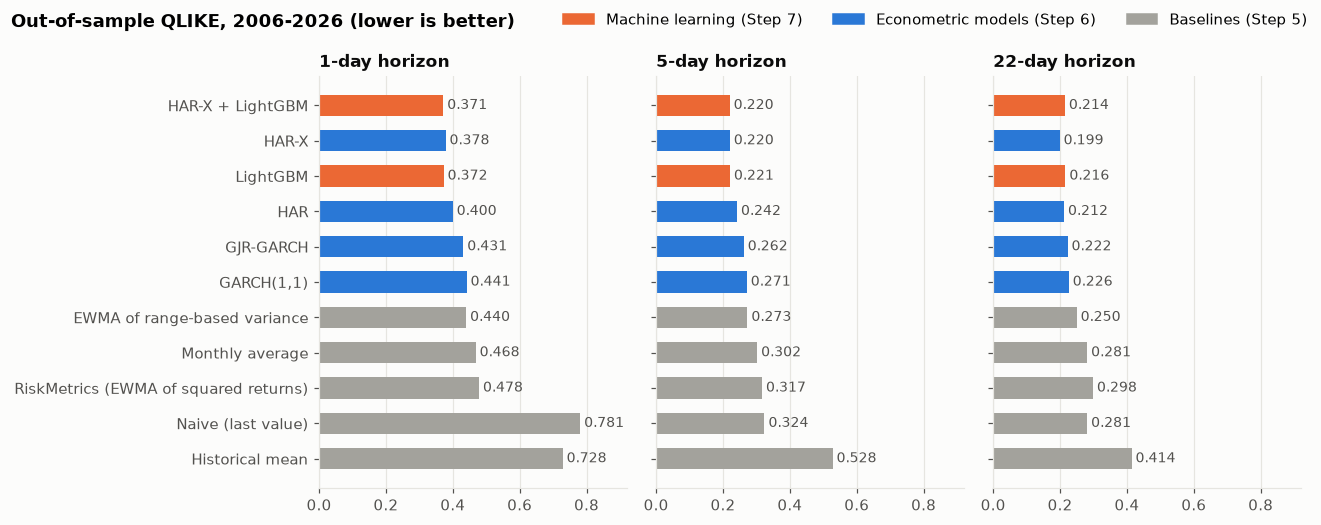

In [4]:
family = overall.drop_duplicates("model_label").set_index("model_label")["family"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.8), sharex=True)
order = table("qlike").index[::-1]
for ax, h in zip(axes, [1, 5, 22]):
    scores = overall[overall["horizon"] == h].set_index("model_label").loc[order, "qlike"]
    ax.barh(scores.index, scores.values, color=[FAMILY_COLORS[family[m]] for m in scores.index], height=0.6)
    for y, v in enumerate(scores.values):
        ax.text(v + 0.012, y, f"{v:.3f}", va="center", color=INK_2, fontsize=9)
    ax.set_title(f"{h}-day horizon", fontsize=11)
    ax.grid(axis="y", visible=False)
    if h != 1:
        ax.set_yticklabels([])
axes[0].set_xlim(0, overall["qlike"].max() * 1.18)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (ORANGE, BLUE, MUTED)]
fig.legend(handles, ["Machine learning (Step 7)", "Econometric models (Step 6)", "Baselines (Step 5)"], loc="upper right", ncols=3)
fig.suptitle("Out-of-sample QLIKE, 2006-2026 (lower is better)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "07_model_scores")
plt.show()

In [5]:
# Change of each loss compared with HAR-X, the best model of Step 6 (negative = better than HAR-X)
reference = overall[overall["model"] == "har_x"].set_index("horizon")
rows = []
for model in ML:
    scores = overall[overall["model"] == model].set_index("horizon")
    for metric, label in [("qlike", "QLIKE"), ("log_mse", "log MSE"), ("mae_vol", "MAE")]:
        rows.append({"model": LABELS[model], "loss": label, **{f"{h} day" + ("s" if h > 1 else ""): scores.loc[h, metric] / reference.loc[h, metric] - 1 for h in (1, 5, 22)}})
versus_harx = pd.DataFrame(rows).set_index(["model", "loss"])
display(versus_harx.map("{:+.1%}".format))

1 day 5 days 22 days
model            loss                         
LightGBM         QLIKE    -1.5%  +0.2%   +8.7%
                 log MSE  -2.5%  -0.2%   +9.8%
                 MAE      -2.4%  -0.1%   +4.9%
HAR-X + LightGBM QLIKE    -1.8%  -0.2%   +8.0%
                 log MSE  -3.7%  -1.2%   +8.2%
                 MAE      -2.6%  -0.2%   +5.3%

**Reading the results.** LightGBM matches HAR-X but does not beat it overall:

* **1 day: slightly better.** QLIKE is 1.5% (LightGBM) to 1.8% (hybrid) lower than HAR-X, and the mean absolute error about 2.5% lower.
* **5 days: a tie.** The three models are within 0.2% of each other on every loss.
* **22 days: worse.** QLIKE is 8 to 9% higher than HAR-X, and even slightly higher than the plain HAR.

The most likely reason for the 22-day result is the amount of independent information. A 22-day target overlaps with its neighbours, so twenty years of daily rows contain only a few hundred truly independent observations per series, and the two validation years about twenty. A flexible model fits noise in that setting, while a linear model with 18 coefficients cannot.

The overall message: **in logarithms, volatility dynamics are close to linear**. Most of what can be forecast is already captured by HAR-X, and the remaining error is largely noise that no model can remove. This is in line with the academic literature, where machine-learning gains over HAR-type models are modest and come mostly from additional predictors rather than from non-linearity.

## 3. Where the models differ

The chart shows, for each test year, the 5-day QLIKE of the two LightGBM models **relative to HAR-X**: below zero, the model beat HAR-X that year.

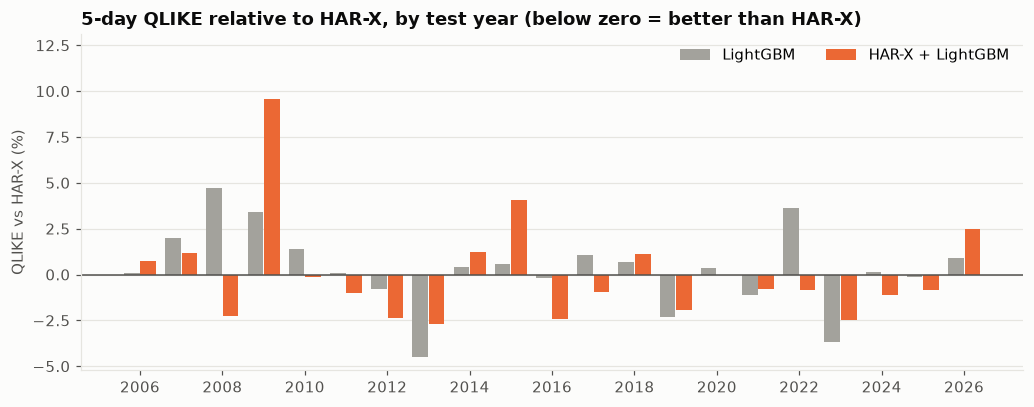

Test years in which the model beat HAR-X: {'LightGBM': 7, 'HAR-X + LightGBM': 14} out of 21


In [6]:
by_year = pd.read_sql("""
    SELECT model, test_year, sum(qlike * n) / sum(n) AS qlike
    FROM model_scores WHERE horizon = 5 AND model IN ('har_x', 'lgbm', 'lgbm_hybrid')
    GROUP BY model, test_year""", engine).pivot(index="test_year", columns="model", values="qlike")
relative = (by_year[ML].div(by_year["har_x"], axis=0) - 1) * 100

fig, ax = plt.subplots(figsize=(9.5, 3.8))
x = np.arange(len(relative))
for i, (model, color) in enumerate([("lgbm", MUTED), ("lgbm_hybrid", ORANGE)]):
    ax.bar(x + (i - 0.5) * 0.4, relative[model], width=0.38, color=color, label=LABELS[model])
ax.axhline(0, color=INK_2, lw=1)
ax.set_xticks(x[::2], relative.index[::2])
ax.grid(axis="x", visible=False)
ax.set_ylabel("QLIKE vs HAR-X (%)")
ax.set_title("5-day QLIKE relative to HAR-X, by test year (below zero = better than HAR-X)")
low, high = relative.min().min(), relative.max().max()
ax.set_ylim(min(low, 0) - 0.05 * (high - low), high + 0.25 * (high - low))    # headroom for the legend
ax.legend(loc="upper right", ncols=2)
fig.tight_layout()
save(fig, "07_vs_harx_by_year")
plt.show()
print("Test years in which the model beat HAR-X:", (relative < 0).sum().rename(LABELS).to_dict(), "out of", len(relative))

In [7]:
stress = " OR ".join(f"f.date BETWEEN '{start}' AND '{end}'" for start, end in CRISES.values())
shown = ["ewma", "har_x", "lgbm", "lgbm_hybrid"]
columns = ", ".join(f"avg(exp(x.target_5d) / f.{m} - ln(exp(x.target_5d) / f.{m}) - 1) AS qlike_{m}, avg(exp(x.target_5d) / f.{m}) AS bias_{m}" for m in shown)
complete = " AND ".join(f"f.{m} IS NOT NULL" for m in overall["model"].unique())
groups = pd.read_sql(f"""
    SELECT CASE WHEN {stress} THEN 'stress periods' ELSE 'calm periods' END AS regime, u.asset_type, count(*) AS n, {columns}
    FROM forecasts f JOIN features x USING (ticker, date) JOIN universe u USING (ticker)
    WHERE f.horizon = 5 AND x.target_5d IS NOT NULL AND {complete}
    GROUP BY 1, 2""", engine)

def weighted(by, prefix):
    out = {}
    for key, g in groups.groupby(by):
        out[key] = {LABELS[m]: np.average(g[f"{prefix}_{m}"], weights=g["n"]) for m in shown}
    return pd.DataFrame(out)

print("QLIKE at the 5-day horizon")
display(weighted("regime", "qlike").join(weighted("asset_type", "qlike")[["stock", "index"]].rename(columns={"stock": "stocks", "index": "indices"})))
print("Average of actual / forecast at the 5-day horizon (1 = no bias, below 1 = forecasts too high)")
display(weighted("asset_type", "bias")[["stock", "index"]].rename(columns={"stock": "stocks", "index": "indices"}))

QLIKE at the 5-day horizon


,calm periods,stress periods,stocks,indices
EWMA of range-based variance,0.267,0.297,0.279,0.237
HAR-X,0.225,0.200,0.228,0.179
LightGBM,0.224,0.206,0.228,0.177
HAR-X + LightGBM,0.224,0.202,0.228,0.174


Average of actual / forecast at the 5-day horizon (1 = no bias, below 1 = forecasts too high)


,stocks,indices
EWMA of range-based variance,1.119,1.093
HAR-X,1.061,0.945
LightGBM,1.055,1.042
HAR-X + LightGBM,1.063,1.040


**Reading the chart and the tables.**

* **The hybrid is more reliable than LightGBM alone.** It beats HAR-X in 14 test years out of 21, LightGBM alone in 7. The difference is clearest in **2008**: LightGBM alone is about 5% worse than HAR-X, because a tree cannot forecast a level of volatility it has never seen, while the hybrid is 2% better because HAR-X carries the level.
* **The hybrid has its bad years too**, in particular 2009 (almost 10% worse), when markets calmed down after the crisis and the corrections learned during the crisis no longer applied.
* **Calm or stress, stocks or indices: no real difference with HAR-X**, except for indices, where the hybrid is 3% better.
* **LightGBM removes the bias on indices.** HAR-X forecasts were 5% too high on average for indices (actual / forecast = 0.945); with the `is_index` feature the trees bring indices in line with stocks (1.04). This is the limitation of pooled linear models noted in Step 6.

## Summary

* **LightGBM matches HAR-X but does not beat it overall:** slightly better at 1 day (QLIKE −1.8% for the hybrid), equal at 5 days, worse at 22 days (+8%).
* **Volatility is close to linear in logarithms.** A regression with 18 coefficients captures almost everything that hundreds of trees can find. The more complex model is not the better one here, and HAR-X remains the reference.
* **How a tree model is used matters:** correcting a linear model (hybrid) is more robust than forecasting from scratch, in particular in a crisis where volatility leaves the range seen in training.
* **Tuning without leakage:** hyperparameters are chosen by Optuna on the last two years of each training window, never on test data. Optuna consistently selects small, regularised trees.

Next: Step 8 tests deep learning models (LSTM, transformer) on sequences of past data. Step 9 will test whether the differences between models are statistically significant.